<a href="https://colab.research.google.com/github/NastyNetwork/apple_quality_classification/blob/main/Apple_klasyfikacja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wstęp:

Projekt ma na celu przeprowadzenie wszechstronnej analizy danych związanych z jakością jabłek w wybranym zbiorze danych. Jabłka są ważnym elementem przemysłu spożywczego, a ich cechy i jakość mają wpływ na decyzje dotyczące produkcji, sortowania oraz sprzedaży. Analiza danych dotyczących jabłek umożliwia lepsze zrozumienie, które cechy decydują o ich jakości oraz identyfikację kluczowych czynników wpływających na ocenę jako „dobre” lub „złe”.

Cel analizy:

Głównym celem analizy jest zgłębienie zależności między różnymi cechami jabłek, takimi jak rozmiar, waga czy słodycz, a ich jakością („good” lub „bad”). Poprzez dogłębne badanie danych, chcę zidentyfikować, które cechy mają największy wpływ na jakość, jakie są trendy w ocenie jabłek oraz jakie czynniki mogą wpływać na ich klasyfikację w przyszłości. Projekt może w przyszłości pozwolić na automatyczne sortowanie jabłek na podstawie dostępnych danych, co może być przydatne dla producentów, przetwórców oraz sprzedawców.

Tytuł projektu: Klasyfikacja jakości jabłek na podstawie cech fizycznych i chemicznych

Struktura danych:
- Identyfikatory jabłka: Unikalne numery, które oznaczają każde jabłko w danych czyli A_id (niepotrzebne)

Cechy jabłek:
- Size (Rozmiar): Wielkość jabłka .

- Weight (Waga): Masa jabłka .

- Sweetness (Słodycz): Poziom słodyczy jabłka.

- Crunchiness (Chrupkość): Stopień chrupkości jabłka.

- Juiciness (Soczystość): Poziom soczystości jabłka.

- Ripeness (Dojrzałość): Stopień dojrzałości jabłka.

- Acidity (Kwasowość): Poziom kwasowości jabłka.

Cechy jakości:
- Quality (Jakość): Kategoria określająca, czy jabłko jest dobre (good 1) czy złe (bad 0), co jest celem klasyfikacji.

Dane do projektu pochodzą z kaggle
- Link: https://www.kaggle.com/datasets/nelgiriyewithana/apple-quality


Import bibliotek:

In [6]:
import pandas as pd  # Obsługa danych w formie tabel, umożliwia wczytywanie i przetwarzanie pliku CSV
import numpy as np  # Obliczenia numeryczne, np. sortowanie wartości cech
import matplotlib.pyplot as plt  # Tworzenie wykresów, takich jak histogramy czy krzywe ROC
import seaborn as sns  # Zaawansowane wizualizacje, np. pairplot czy wykresy skrzynkowe
from sklearn.model_selection import train_test_split  # Podział danych na zbiór treningowy i testowy
from sklearn.linear_model import LogisticRegression  # Model regresji logistycznej do klasyfikacji
from sklearn.tree import DecisionTreeClassifier  #Model drzewa decyzyjnego, który dzieli dane na grupy na podstawie reguł; wybrany, aby porównać różne podejścia do klasyfikacji
from sklearn.ensemble import RandomForestClassifier  #Model lasu losowego, który łączy wiele drzew decyzyjnych dla lepszej dokładności; wybrany ze względu na wysoką skuteczność w klasyfikacji
from sklearn.svm import SVC  # Model maszyny wektorów nośnych do klasyfikacji
from sklearn.neural_network import MLPClassifier  #Model sieci neuronowej, który uczy się złożonych wzorców; wybrany, aby przetestować zaawansowane podejście
from sklearn.metrics import accuracy_score  # Obliczanie dokładności modeli
from sklearn.metrics import classification_report  # Szczegółowa ocena modeli (precyzja, czułość, F1-score)
from sklearn.metrics import confusion_matrix  #Tworzenie macierzy pomyłek, która pokazuje błędy klasyfikacji; wybrana do wizualnej oceny wyników
from sklearn.metrics import roc_curve, auc  #Obliczanie krzywej ROC i AUC do oceny zdolności modeli do rozróżniania klas; wybrana jako standard w klasyfikacji
from sklearn.model_selection import GridSearchCV  #Optymalizacja parametrów modelu poprzez testowanie różnych kombinacji; wybrana do poprawy skuteczności lasu losowego

Analiza struktury danych:

In [7]:
# Wczytane dane z pliku 'apple_quality.csv' zawierają informacje o jabłkach, takie jak rozmiar, waga,
# słodycz, chrupkość, soczystość, dojrzałość, kwasowość oraz jakość ('good' lub 'bad').
df = pd.read_csv('apple_quality.csv')

# Wyświetlone pierwsze 5 wierszy danych w celu sprawdzenia ich struktury i zawartości.
print("Pierwsze 5 wierszy danych:")
print(df.head())

# Uswanie kolumny 'A_id', jeśli istnieje, ponieważ jest to identyfikator i nie wpływa na analizę.
# errors='ignore', aby uniknąć błędu w przypadku braku tej kolumny.
df = df.drop('A_id', axis=1, errors='ignore')

# Przekształcone wszystkie kolumny (oprócz 'Quality') na wartości numeryczne, zamieniając niepoprawne wartości
# (np. tekst) na NaN, aby usunąć błędne dane, takie jak 'Created_by_Nidula_Elgiriyewithana'.
for col in df.columns:
    if col != 'Quality':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Usuwanie wierszy zawierających wartości NaN, powstałych po zamianie błędnych danych.
df = df.dropna()

# Wyświetlone typy danych po czyszczeniu.
print("\nTypy danych po czyszczeniu:")
print(df.dtypes)

# Wyświetlenie informacji o brakujących danych po czyszczeniu w celu weryfikacji kompletności danych.
print("\nBrakujące dane w kolumnach po czyszczeniu:")
print(df.isnull().sum())

# Wyświetlenie podstawowych statystyk (średnia, minimum, maksimum itp.) w celu zrozumienia rozkładów cech.
print("\nPodstawowe statystyki danych po czyszczeniu:")
print(df.describe())

Pierwsze 5 wierszy danych:
   A_id      Size    Weight  Sweetness  Crunchiness  Juiciness  Ripeness  \
0   0.0 -3.970049 -2.512336   5.346330    -1.012009   1.844900  0.329840   
1   1.0 -1.195217 -2.839257   3.664059     1.588232   0.853286  0.867530   
2   2.0 -0.292024 -1.351282  -1.738429    -0.342616   2.838636 -0.038033   
3   3.0 -0.657196 -2.271627   1.324874    -0.097875   3.637970 -3.413761   
4   4.0  1.364217 -1.296612  -0.384658    -0.553006   3.030874 -1.303849   

        Acidity Quality  
0  -0.491590483    good  
1  -0.722809367    good  
2   2.621636473     bad  
3   0.790723217    good  
4   0.501984036    good  

Typy danych po czyszczeniu:
Size           float64
Weight         float64
Sweetness      float64
Crunchiness    float64
Juiciness      float64
Ripeness       float64
Acidity        float64
Quality         object
dtype: object

Brakujące dane w kolumnach po czyszczeniu:
Size           0
Weight         0
Sweetness      0
Crunchiness    0
Juiciness      0
Ripe

Analiza eksploracyjna danych – wykres słupkowy i wykresy skrzynkowe:


Wykres słupkowy rozkładu jakości jabłek:
Wykres pokazuje, ile jabłek jest dobrej ('good') i złej ('bad') jakości.


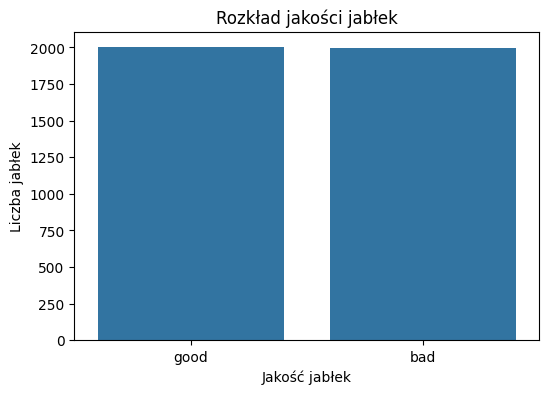


Wykresy skrzynkowe dla każdej cechy:
Wykresy pokazują rozkład cech, takich jak rozmiar czy słodycz, dla jabłek dobrej i złej jakości. Większe różnice wskazują na cechy ważne dla klasyfikacji.


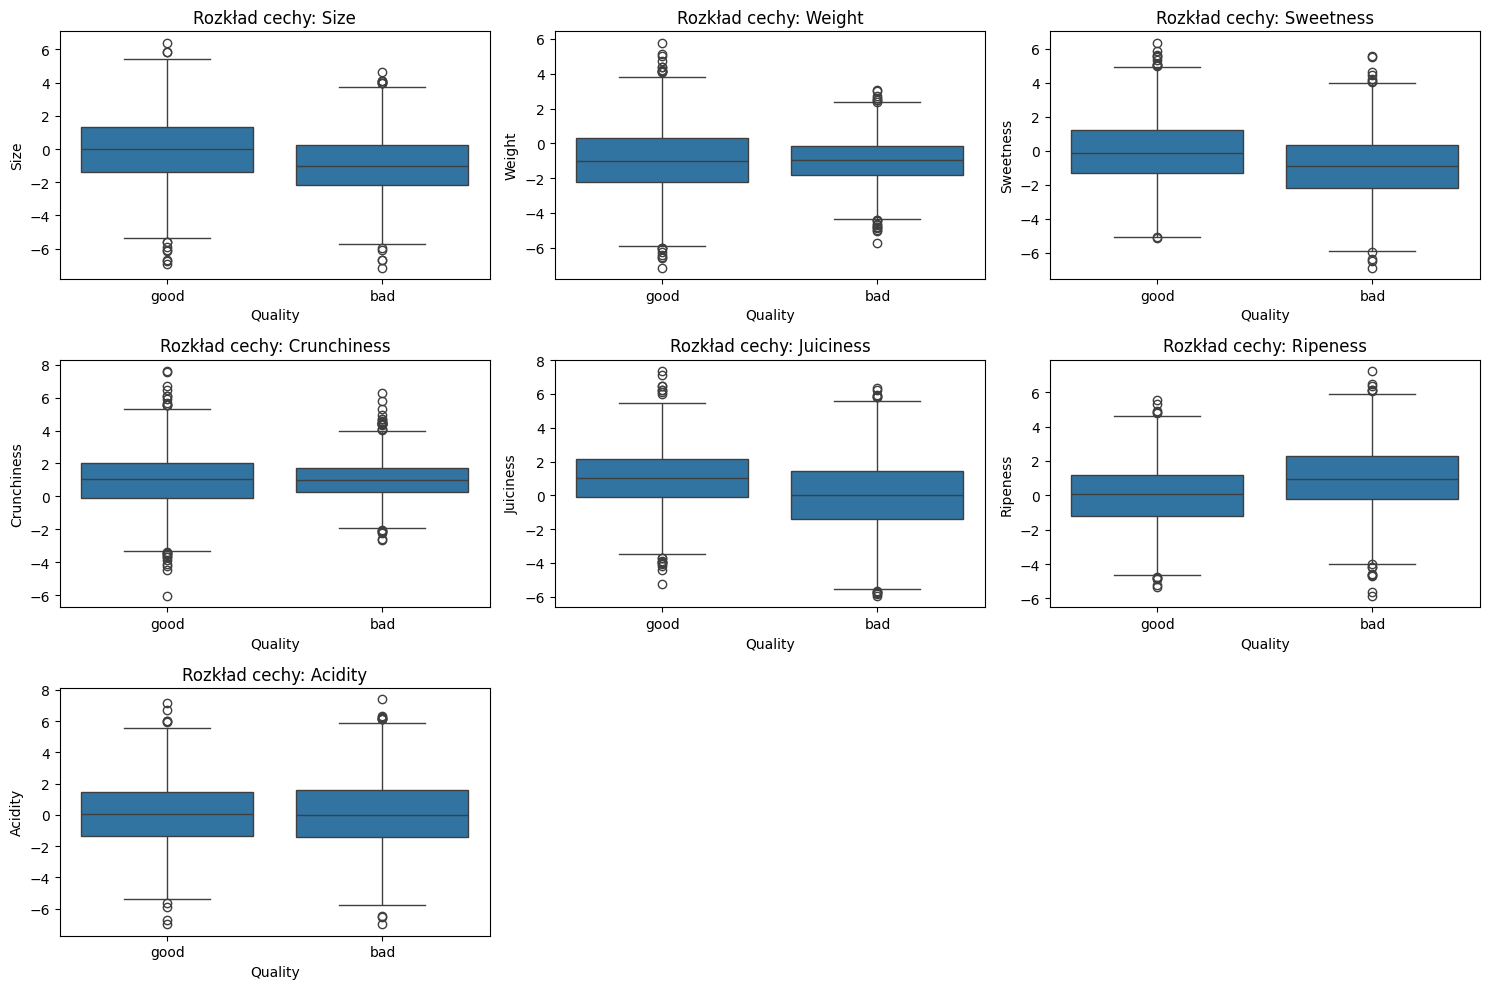

In [8]:
# Wykres słupkowy pokazujący rozkład jakości jabłek ('good' i 'bad').
# Umożliwia ocenę, czy dane są zbalansowane.
print("\nWykres słupkowy rozkładu jakości jabłek:")
print("Wykres pokazuje, ile jabłek jest dobrej ('good') i złej ('bad') jakości.")
plt.figure(figsize=(6,4))
sns.countplot(x='Quality', data=df)
plt.title('Rozkład jakości jabłek')
plt.xlabel('Jakość jabłek')
plt.ylabel('Liczba jabłek')
plt.show()

# Wykresy skrzynkowe dla każdej cechy, pokazujące ich rozkład dla jabłek dobrej i złej jakości.
# Wykresy te przedstawiają medianę, zakres i wartości odstające, pomagając ocenić różnice między klasami.
print("\nWykresy skrzynkowe dla każdej cechy:")
print("Wykresy pokazują rozkład cech, takich jak rozmiar czy słodycz, dla jabłek dobrej i złej jakości. Większe różnice wskazują na cechy ważne dla klasyfikacji.")
plt.figure(figsize=(15,10))
for i, col in enumerate(df.drop('Quality', axis=1).columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='Quality', y=col, data=df)
    plt.title(f'Rozkład cechy: {col}')
plt.tight_layout()
plt.show()

Analiza eksploracyjna danych – Pairplot i macierz korelacji:


Pairplot dla wszystkich cech:
Wykres pokazuje relacje między wszystkimi cechami (np. rozmiar vs słodycz) z podziałem na jakość.


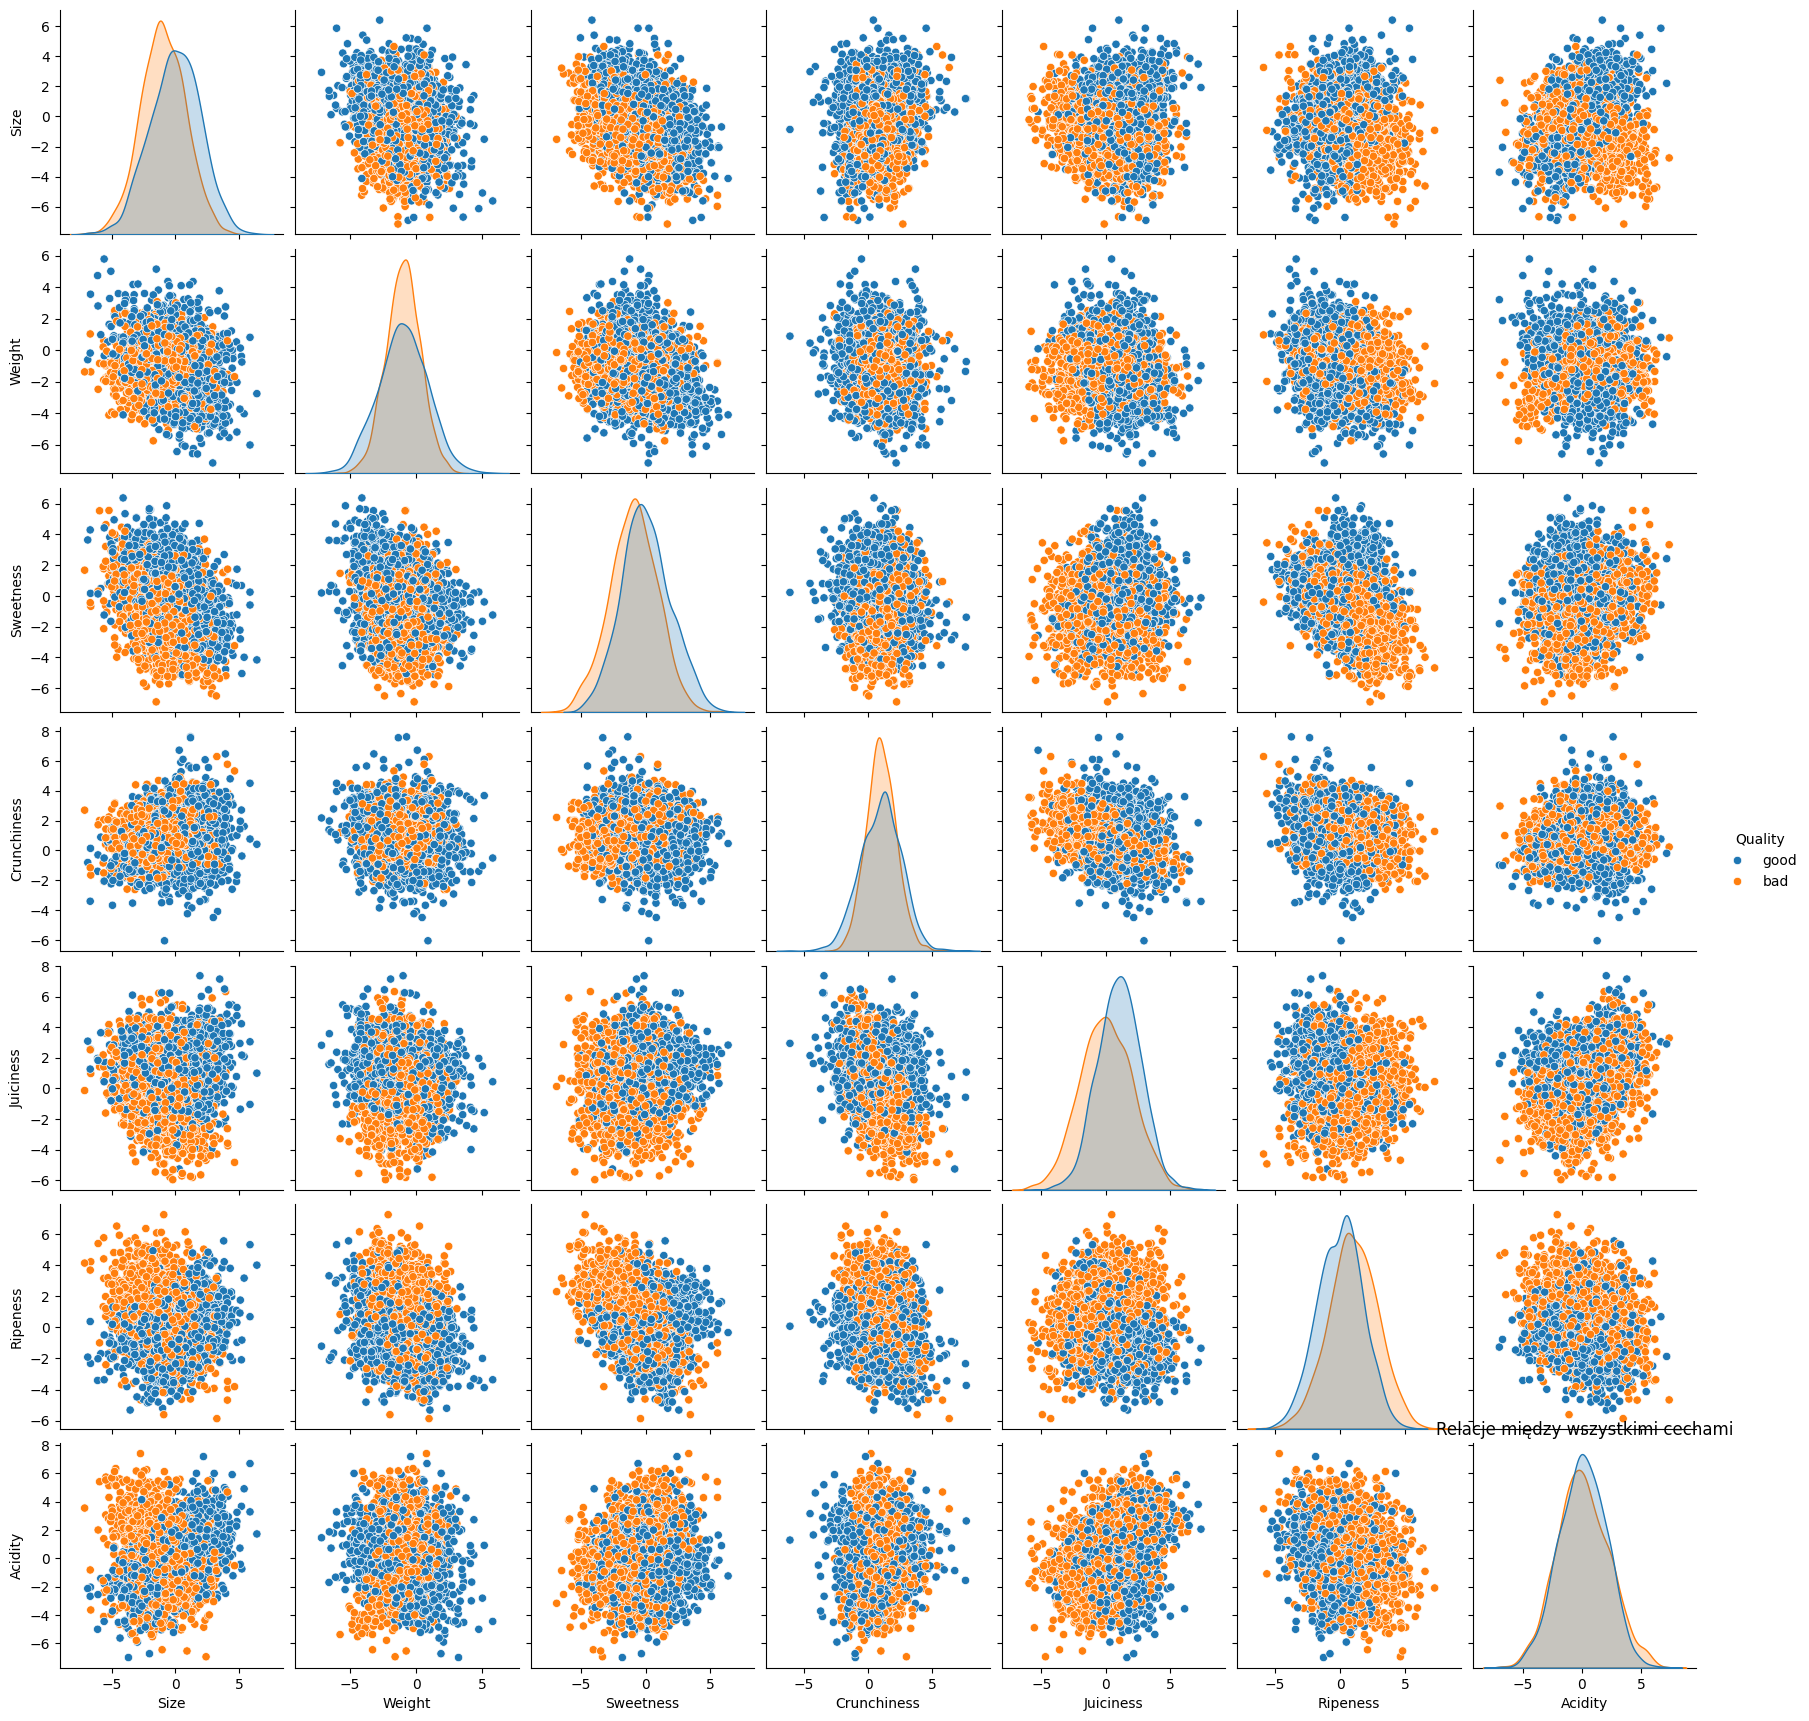


Macierz korelacji cech:
Wykres pokazuje, jak cechy są powiązane – wartości bliskie 1 lub -1 oznaczają silną zależność.


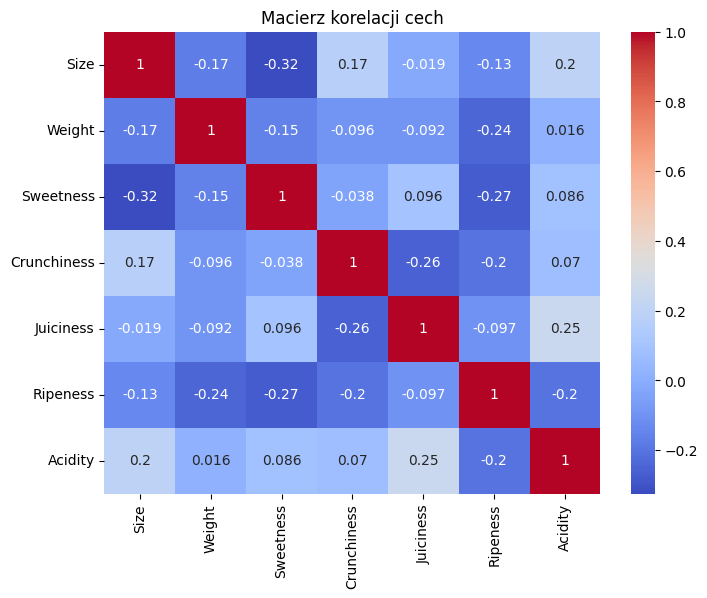

In [9]:
# Pairplot dla wszystkich cech, pokazujący relacje między nimi oraz ich rozkłady z podziałem na jakość.
# Umożliwia identyfikację cech, które dobrze różnicują jabłka dobrej i złej jakości.
print("\nPairplot dla wszystkich cech:")
print("Wykres pokazuje relacje między wszystkimi cechami (np. rozmiar vs słodycz) z podziałem na jakość.")
sns.pairplot(df, hue='Quality')
plt.title('Relacje między wszystkimi cechami')
plt.show()

# Obliczona macierz korelacji dla cech numerycznych w celu analizy zależności między nimi.
# Wysoka korelacja (bliska 1 lub -1) wskazuje na podobieństwo cech, co może sugerować redundancję (nadmiarowość informacji, gdy cechy przekazują podobne dane).
print("\nMacierz korelacji cech:")
print("Wykres pokazuje, jak cechy są powiązane – wartości bliskie 1 lub -1 oznaczają silną zależność.")
corr = df.drop('Quality', axis=1).corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Macierz korelacji cech')
plt.show()

Przygotowanie danych:

In [10]:
# Przekształcona kolumna 'Quality' na wartości numeryczne: 'good' -> 1, 'bad' -> 0.
# Modele uczenia maszynowego wymagają danych numerycznych, a nie tekstowych.
df['Quality'] = df['Quality'].map({'good': 1, 'bad': 0})

# Oddzielone cechy (X), czyli informacje o jabłkach, od zmiennej docelowej (y), czyli jakości.
X = df.drop('Quality', axis=1)
y = df['Quality']

# Podzielone dane na zbiór treningowy (80%) i testowy (20%).
# Zbiór treningowy służy do nauki modeli, a testowy do oceny ich skuteczności.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Modelowanie danych - regresja logistyczna:

In [11]:
# Słownik do przechowywania dokładności modeli w celu późniejszego porównania.
model_accuracies = {}

# Model regresji logistycznej do przewidywania prawdopodobieństwa przynależności do klasy 'good'.
log_reg = LogisticRegression(max_iter=1000) # max iter = 1000 algorytm bedzie próbował dopasować się maksymalnie prez 1000 iteracji
log_reg.fit(X_train, y_train) # nauka modelu
y_pred_log_reg = log_reg.predict(X_test)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg) # prówanie przewidywanych etykiet (y_pred_log_reg) z prawdziwymi etykietami (y_test)
model_accuracies['Regresja logistyczna'] = accuracy_log_reg # zapisanie wyików w słowniku
print('\nRegresja logistyczna - Dokładność:', accuracy_log_reg)
print(classification_report(y_test, y_pred_log_reg))


Regresja logistyczna - Dokładność: 0.75375
              precision    recall  f1-score   support

           0       0.75      0.76      0.75       401
           1       0.75      0.75      0.75       399

    accuracy                           0.75       800
   macro avg       0.75      0.75      0.75       800
weighted avg       0.75      0.75      0.75       800



Modelowanie danych - Drzewo decyzyjne:

In [12]:
# Model drzewa decyzyjnego, który dzieli dane na grupy na podstawie wartości cech.
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train) # nauka drzewa na danych treningowych
y_pred_tree = tree.predict(X_test) # model przewiduje etykiety dla danych testowych
accuracy_tree = accuracy_score(y_test, y_pred_tree) # obliczanie dokładności
model_accuracies['Drzewo decyzyjne'] = accuracy_tree # dodanie wartości do słownika, pod etykietą Drzewo decyzyjne
print('\nDrzewo decyzyjne - Dokładność:', accuracy_tree)
print(classification_report(y_test, y_pred_tree))


Drzewo decyzyjne - Dokładność: 0.8
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       401
           1       0.80      0.80      0.80       399

    accuracy                           0.80       800
   macro avg       0.80      0.80      0.80       800
weighted avg       0.80      0.80      0.80       800



Modelowanie danych - Las losowy:

In [13]:
# Model lasu losowego, który łączy wiele drzew decyzyjnych dla lepszej dokładności.
forest = RandomForestClassifier()
forest.fit(X_train, y_train) # nauka na danych treningowych
y_pred_forest = forest.predict(X_test) # przewidywanie etykiet dal zbioru testowego
accuracy_forest = accuracy_score(y_test, y_pred_forest) # liczenie dokładności lasu losowego
model_accuracies['Las losowy'] = accuracy_forest # zapis wyniku w słowniku pod nazwą Las losowy
print('\nLas losowy - Dokładność:', accuracy_forest)
print(classification_report(y_test, y_pred_forest))


Las losowy - Dokładność: 0.89875
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       401
           1       0.90      0.90      0.90       399

    accuracy                           0.90       800
   macro avg       0.90      0.90      0.90       800
weighted avg       0.90      0.90      0.90       800



Modelowanie danych - SVM:

In [14]:
# Model SVM, który szuka granicy najlepiej oddzielającej klasy 'good' i 'bad'.
svm = SVC(probability=True)  # Włączona opcja probability=True do obliczania krzywej ROC
svm.fit(X_train, y_train) # nauka modelu na danych treningowych
y_pred_svm = svm.predict(X_test) # przewidywanie etykiety dla danych testowych
accuracy_svm = accuracy_score(y_test, y_pred_svm) # obliczenie dokładności SVM
model_accuracies['SVM'] = accuracy_svm # zapisanie w słowniku
print('\nSVM - Dokładność:', accuracy_svm)
print(classification_report(y_test, y_pred_svm))


SVM - Dokładność: 0.9075
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       401
           1       0.90      0.91      0.91       399

    accuracy                           0.91       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.91      0.91      0.91       800



Modelowanie danych - Sieć neuronowa:

In [15]:
# Model sieci neuronowej do wychwytywania złożonych wzorców w danych.
nn = MLPClassifier(max_iter=1000) # maxiter=1000 oznacza limit iteracji dla algorytmu uczącego
nn.fit(X_train, y_train) # nauka na zbiorze treningowym
y_pred_nn = nn.predict(X_test) # pzewidywanie etykiety dla zbioru testowego
accuracy_nn = accuracy_score(y_test, y_pred_nn) # obliczanie dokladnosci sieci
model_accuracies['Sieć neuronowa'] = accuracy_nn # Wyniki dodawane sa do slownika
print('\nSieć neuronowa - Dokładność:', accuracy_nn)
print(classification_report(y_test, y_pred_nn))


Sieć neuronowa - Dokładność: 0.955
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       401
           1       0.96      0.95      0.95       399

    accuracy                           0.95       800
   macro avg       0.96      0.95      0.95       800
weighted avg       0.96      0.95      0.95       800



Prezentacja wyników - Macierz pomyłek i krzywa ROC:


Macierz pomyłek dla lasu losowego:
Wykres pokazuje, ile jabłek zostało poprawnie (przekątna) i błędnie sklasyfikowanych. Wartości poza przekątną wskazują na błędy modelu.


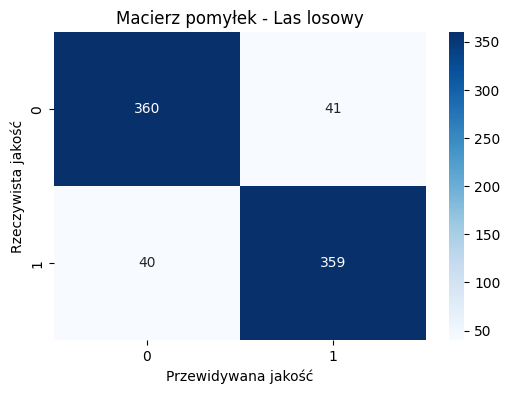


Krzywe ROC dla wszystkich modeli:
Wykres pokazuje, jak dobrze modele odróżniają jabłka dobrej i złej jakości.
AUC (Area Under Curve) to pole pod krzywą – im bliżej 1, tym model jest lepszy.


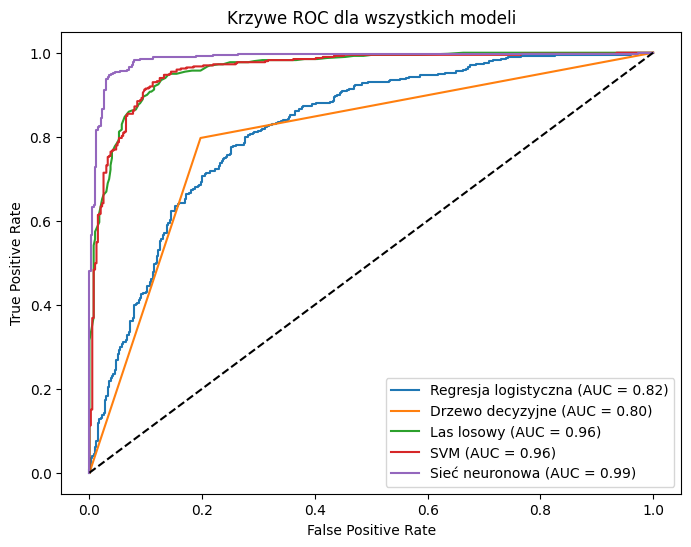

In [16]:
# Macierz pomyłek pokazująca, ile jabłek zostało poprawnie i błędnie sklasyfikowanych.
print("\nMacierz pomyłek dla lasu losowego:")
print("Wykres pokazuje, ile jabłek zostało poprawnie (przekątna) i błędnie sklasyfikowanych. Wartości poza przekątną wskazują na błędy modelu.")
cm = confusion_matrix(y_test, y_pred_forest) # macierz pomyłek: dla prawdziwej klasy wiersze i przewidywanej kolumny, zlicza się liczbe przypadków
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') # komórkach (annot=True), format liczbowy całkowity ('d')
plt.title('Macierz pomyłek - Las losowy')
plt.xlabel('Przewidywana jakość')
plt.ylabel('Rzeczywista jakość')
plt.show()

# Krzywe ROC dla każdego modelu, pokazujące ich zdolność do rozróżniania klas.
# AUC (pole pod krzywą) wskazuje skuteczność modelu – im bliżej 1, tym lepiej.
print("\nKrzywe ROC dla wszystkich modeli:")
print("Wykres pokazuje, jak dobrze modele odróżniają jabłka dobrej i złej jakości.")
print("AUC (Area Under Curve) to pole pod krzywą – im bliżej 1, tym model jest lepszy.")
plt.figure(figsize=(8,6))
#Dla każdego modelu: policzę prawdopodobieństwa przynależności do klasy 'good'
# (dla SVM i regresji potrzebujemy probability=True, by predict_proba działało)
for model, name in [(log_reg, 'Regresja logistyczna'), (tree, 'Drzewo decyzyjne'),
                    (forest, 'Las losowy'), (svm, 'SVM'), (nn, 'Sieć neuronowa')]:
    y_prob = model.predict_proba(X_test)[:,1] # predict_proba zwraca 2 kolumny, jest [0,1] czyli prawdopodobieństwo dla kasy good
    fpr, tpr, _ = roc_curve(y_test, y_prob)     # Obliczam false positive rate (FPR) i true positive rate (TPR) dla różnych progów decyzyjnych.
    roc_auc = auc(fpr, tpr) # obliczanie AUC (pole pod krzywą ROC)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')  # Linia losowego zgadywania
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywe ROC dla wszystkich modeli')
plt.legend()
plt.show()

Ważność cech i histogramy:


Ważność cech dla lasu losowego:
Wykres pokazuje, które cechy mają największy wpływ na przewidywanie jakości jabłek.


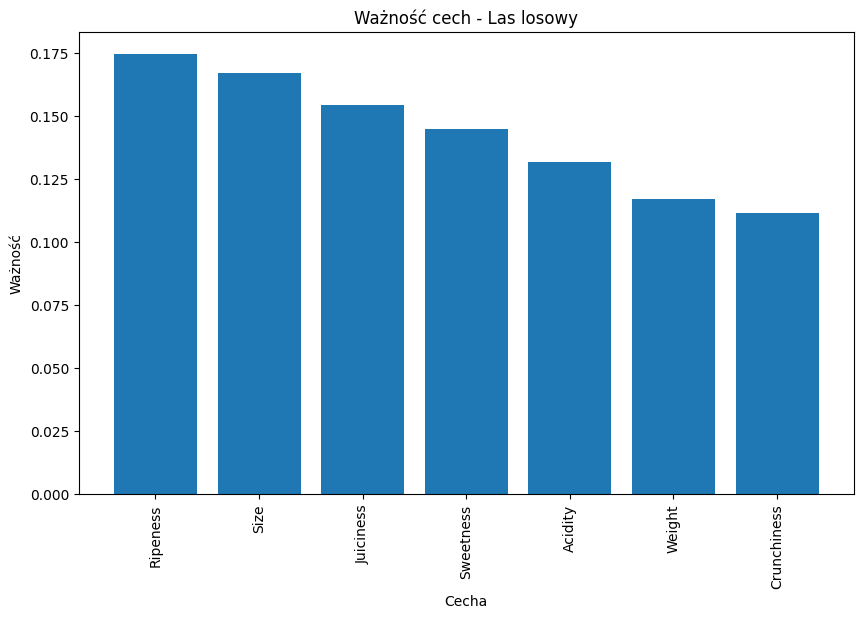


Histogramy dla dwóch najważniejszych cech:
Wykresy pokazują rozkład dwóch kluczowych cech (np. słodycz, rozmiar) dla jabłek dobrej i złej jakości.


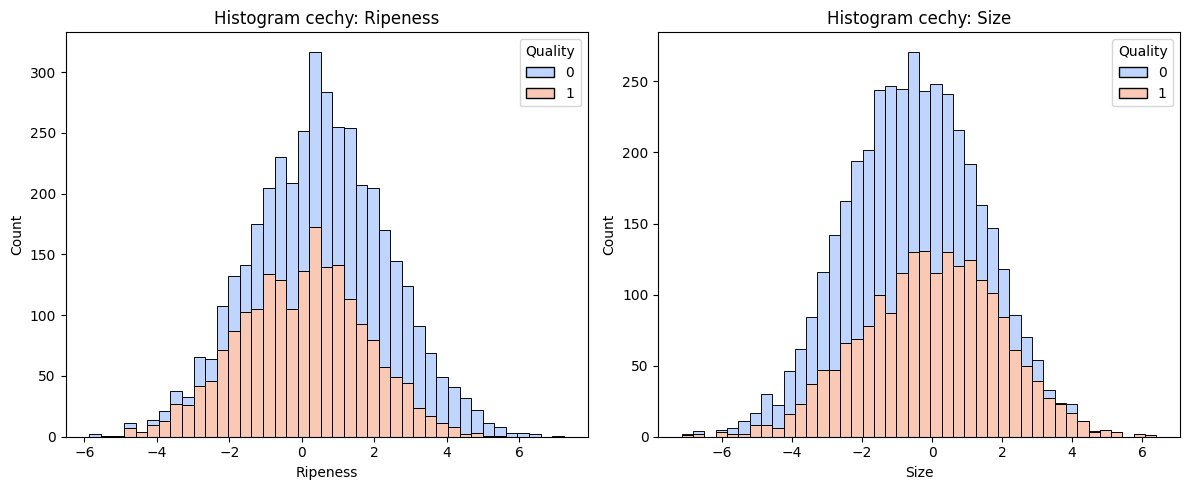

In [17]:
# Wykres pokazujący, które cechy (np. rozmiar, słodycz) są najważniejsze dla lasu losowego.
print("\nWażność cech dla lasu losowego:")  # Wyświetla nagłówek dla wykresu.
print("Wykres pokazuje, które cechy mają największy wpływ na przewidywanie jakości jabłek.")  # Wyjaśnia, co widać na wykresie, na co patrzeć i co może się wyróżniać.
importances = forest.feature_importances_  # Zapisuje, jak ważne są poszczególne cechy dla modelu lasu losowego.
indices = np.argsort(importances)[::-1]  # Sortuje cechy od najbardziej do najmniej ważnych, żeby łatwiej je porównać.
plt.figure(figsize=(10,6))
plt.title('Ważność cech - Las losowy')
plt.bar(range(X.shape[1]), importances[indices], align='center')  # Rysuje słupki pokazujące ważność każdej cechy.
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)  # Oznacza cechy na osi X, obracając nazwy, żeby się mieściły.
plt.xlabel('Cecha')
plt.ylabel('Ważność')
plt.show()

# Histogramy dla dwóch najważniejszych cech, pokazujące ich rozkład dla jabłek dobrej i złej jakości.
print("\nHistogramy dla dwóch najważniejszych cech:")
print("Wykresy pokazują rozkład dwóch kluczowych cech (np. słodycz, rozmiar) dla jabłek dobrej i złej jakości.")
top_features = X.columns[indices[:2]]  # Wybiera dwie cechy, które są najbardziej ważne według modelu.
plt.figure(figsize=(12,5))
for i, feature in enumerate(top_features, 1):  # Przechodzi po dwóch najważniejszych cechach, tworząc dla każdej osobny histogram.
    plt.subplot(1, 2, i)
    sns.histplot(data=df, x=feature, hue='Quality', multiple='stack', palette='coolwarm')
    plt.title(f'Histogram cechy: {feature}')
plt.tight_layout()
plt.show()

Porównanie dokładności modeli:


Porównanie dokładności modeli:
Wykres pokazuje dokładność każdego modelu – wyższy słupek oznacza lepszy wynik.


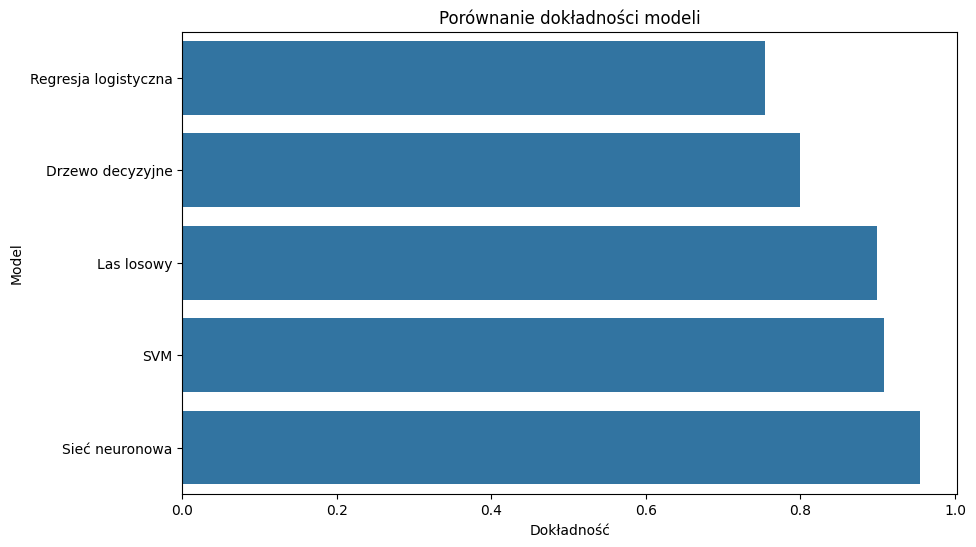

In [18]:
# Wykres słupkowy porównujący dokładność wszystkich modeli.
print("\nPorównanie dokładności modeli:")
print("Wykres pokazuje dokładność każdego modelu – wyższy słupek oznacza lepszy wynik.")
plt.figure(figsize=(10,6))
sns.barplot(x=list(model_accuracies.values()), y=list(model_accuracies.keys()))
plt.title('Porównanie dokładności modeli')
plt.xlabel('Dokładność')
plt.ylabel('Model')
plt.show()

Wnioski:

In [19]:
# Najlepszy model na podstawie dokładności.
best_model = max(model_accuracies, key=model_accuracies.get)  # Znajduje model, który miał najwyższą dokładność wśród wszystkich przetestowanych modeli.
best_accuracy = model_accuracies[best_model]  # Zapisuje dokładność (procent poprawnych przewidywań) dla tego najlepszego modelu.

# Wypisane wnioski podsumowujące projekt, w tym wyniki modeli.
print("\nWnioski:")
print(f"1. Przeanalizowane dane w celu zrozumienia wpływu cech jabłek na ich jakość.")
print(f"2. Przygotowane dane poprzez zamianę tekstu na liczby i podział na zbiory treningowy i testowy.")
print(f"3. Zbudowałem pięć modeli i porównałem ich skuteczność. Najlepiej spisał się model {best_model} z dokładnością {best_accuracy:.2f}.")
print(f"4. Stworzone wizualizacje, takie jak histogramy, wykresy skrzynkowe i krzywe ROC, w celu lepszego zrozumienia danych i modeli.")
print(f"Zastosowanie: Model {best_model} może być użyty w przemyśle spożywczym do automatycznego sortowania jabłek.")


Wnioski:
1. Przeanalizowane dane w celu zrozumienia wpływu cech jabłek na ich jakość.
2. Przygotowane dane poprzez zamianę tekstu na liczby i podział na zbiory treningowy i testowy.
3. Zbudowałem pięć modeli i porównałem ich skuteczność. Najlepiej spisał się model Sieć neuronowa z dokładnością 0.95.
4. Stworzone wizualizacje, takie jak histogramy, wykresy skrzynkowe i krzywe ROC, w celu lepszego zrozumienia danych i modeli.
Zastosowanie: Model Sieć neuronowa może być użyty w przemyśle spożywczym do automatycznego sortowania jabłek.
